In [1]:
import numpy as np 
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1.) Create Batch of I-V curves

In [7]:
from calculate_iv_curve import simulate_iv_curve

batch_size = 200
seed_0 = 420

control_indices = [1, 2, 3, 4, 6, 7]

for i in range(batch_size):

    control_voltages = np.random.uniform(-1.5, 1.5, size=(len(control_indices), ))
    control_voltages_dict = {
        idx: voltage for idx, voltage in zip(control_indices, control_voltages)
    }
    simulate_iv_curve(name=i, seed=i, params=control_voltages_dict)

num_of_curves: 200


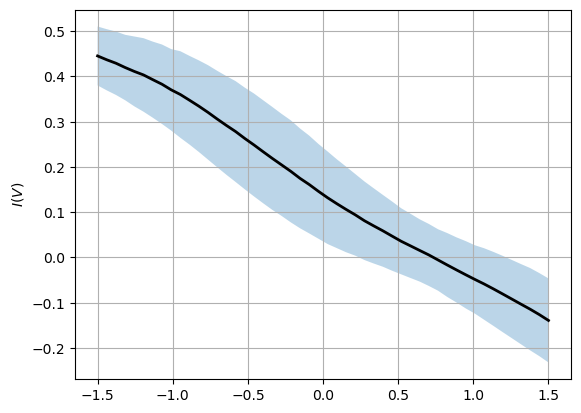

In [12]:
curve_list = []
print(f"num_of_curves: {batch_size}")
for i in range(batch_size):
    _curve = np.load(f"../../data/iv_curves/data_point_{i}.npz")
    curve_list.append(_curve["outputCurrent"])

np.save(file="../../data/batch_200_samples_truncnorm_1/curves_200_1.npy", arr=np.array(curve_list))

iv_curves = np.load(file="../../data/batch_200_samples_truncnorm_1/curves_200_1.npy")
num_of_points = iv_curves[0].shape[0]

mean = np.mean(iv_curves, axis=0)
std_dev = np.std(iv_curves, ddof=1, axis=0)

vs = np.linspace(-1.5, 1.5, iv_curves.shape[1])
plt.plot(vs, mean, lw=2., c='k')
plt.fill_between(vs, mean-std_dev, mean+std_dev, alpha=.3)
plt.ylabel("$I(V)$")
plt.grid(True)

# 2.) Truncated Normal Geometry

In [2]:
radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.
cov_matrix = (std_dev ** 2) * np.eye(2)

7.978845608028652
3.191538243211461


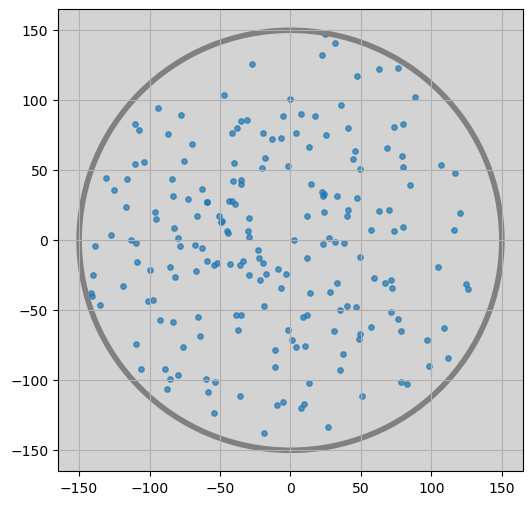

In [6]:
if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < 200:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


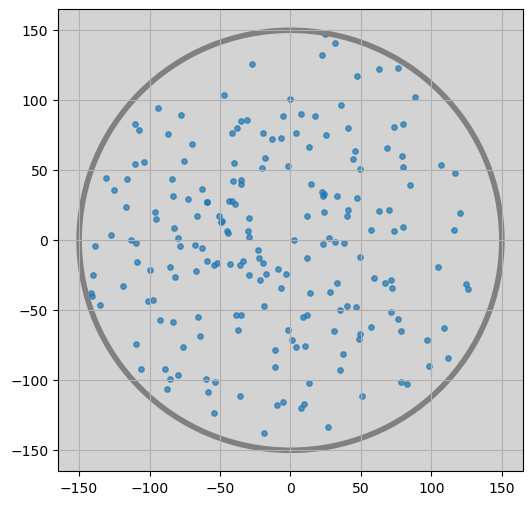

In [13]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']


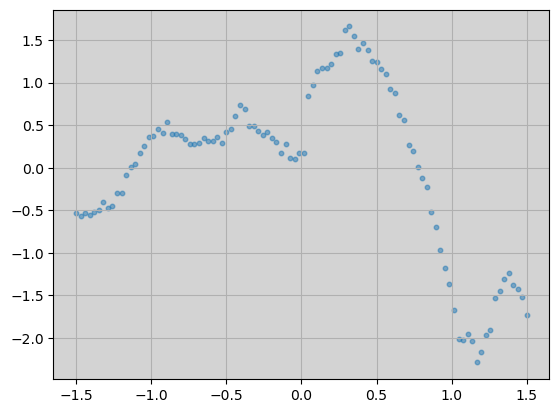

In [91]:
data = np.load("../../data/batch_10002.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 10.5,
    "alpha": .5,
}

fig, ax = plt.subplots()

output_mean = np.mean(data["outputs"][0, :])
output_std = np.std(data["outputs"][0, :], ddof=1)
normalized_outputs = (data["outputs"][0, :] - output_mean) / output_std

ax.scatter(vs, normalized_outputs, **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

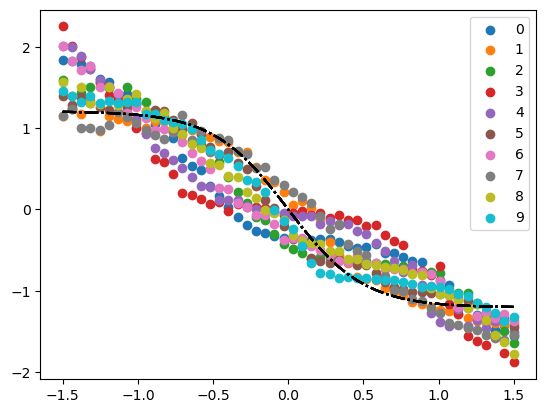

In [132]:
curves = []

num_of_plots = 10
for i in range(num_of_plots):
    data = np.load(f"../../data/trials/data_point_{i}.npz")
    out = data["outputCurrent"]
    out = (out - np.mean(out)) / np.std(out, ddof=1)
    curves.append(out)
vs = np.linspace(-1.5, 1.5, curves[0].shape[0])

def target(x):
    return 1 / (1 + np.exp(4*x))

targets = target(vs)
normalized_targets = (targets - np.mean(targets)) / np.std(targets, ddof=1)

fig, ax = plt.subplots()
for i in range(num_of_plots):
    ax.scatter(vs, curves[i], label=f"{i}")
    ax.plot(vs, normalized_targets, color='k', linestyle="-.")
    plt.legend()

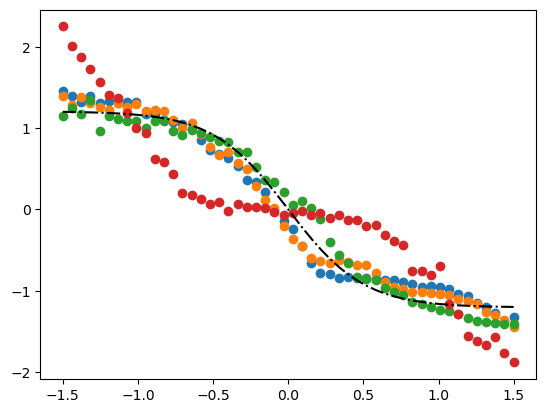

In [137]:
plt.scatter(vs, curves[9])
plt.scatter(vs, curves[5])
plt.scatter(vs, curves[1])
plt.scatter(vs, curves[3])
plt.plot(vs, normalized_targets, color='k', linestyle="-.")